In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('Mall_Customers.csv')
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
x=dataset.iloc[:,[3,4]].values

In [20]:
from sklearn.cluster import OPTICS
op = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.09)
y_op=op.fit_predict(x)

In [21]:
from sklearn.metrics import silhouette_score
labels=y_op
mask=labels !=1
if(len(set(labels[mask]))>1):
    ss=silhouette_score(x[mask],labels[mask])
    print("Silhoutee Score:",ss,)
else:
    print("Only one cluster or noise")

Silhoutee Score: 0.12212717437216522


In [22]:
y_op

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1, -1,  0,
       -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
       -1, -1, -1, -1,  3, -1,  3, -1,  3,  2,  3,  2,  3, -1,  3,  2,  3,
        2,  3,  2,  3,  2,  3, -1,  3,  2,  3, -1,  3,  2,  3,  2,  3,  2,
        3,  2,  3,  2,  3,  2,  3, -1,  3,  2,  3,  2,  3,  2,  3,  2,  3,
        2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3,  2,  3, -1,  3,  2,
        3,  2,  3,  2, -1, -1,  3, -1, -1, -1, -1, -1, -1])

In [23]:
supervised=dataset
supervised["cluster"]=y_op
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,-1
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,-1
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [24]:
supervised.to_csv("Clustered_Mall_Customers.csv",index=False)

C:\Users\Jayashree M\.conda\envs\hopeai\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


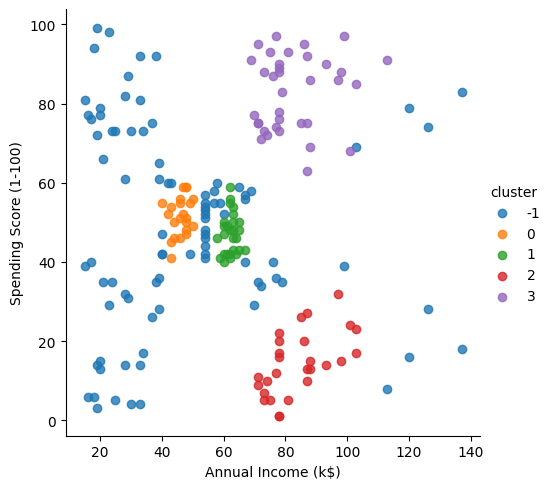

In [25]:
import seaborn as sns 
facet=sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue=supervised.columns[5],fit_reg=False,legend=True,legend_out=True)
